# Problema 1

In [ ]:
import torch

In [ ]:
A = torch.tensor([[4., 5.],
                  [-2., 1.],
                  [0., 6.]])

B = torch.tensor([[3., 0., -1.],
                  [2., 2., 10.]])

print(A.shape)
print(B.shape)

torch.Size([3, 2])
torch.Size([2, 3])


In [ ]:
C = B[0] + torch.mm(A, B)

x = A[:, 1]

x.requires_grad_(True)

f = -torch.sum(C[0] * (x * x))

f.backward()

print(x.grad)

tensor([-250.,  -20., -540.])


# Problema 2

## cu ridge

In [ ]:
import torch
from torch import nn
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

def synthetic_data(w, b):
    X = torch.rand(250).reshape(-1, 1)
    y = X @ w + b
    y += torch.rand(250) / 4
    return X, y.reshape(-1, 1)

true_w = torch.tensor([2.])
true_b = 3
features, labels = synthetic_data(true_w, true_b)

def load_array(data_arrays, batch_size, is_train=True):
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

net = nn.Sequential(nn.Linear(1, 1))

net[0].weight.data.fill_(1)
net[0].bias.data.fill_(0)

def my_loss(y_hat, y):
    squared_error = (y_hat - y) ** 2
    return torch.mean(squared_error)


loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

loss = my_loss
optimizer2 = torch.optim.SGD(net.parameters(), lr=0.1)
lambda_param = 0.1
num_epochs = 15

for epoch in range(num_epochs):
    for X, y in data_iter:
        output = net(X)
        l = loss_fn(output, y)

        w_param = net[0].weight
        l2_penalty = (lambda_param * torch.sum(w_param ** 2)) / 2

        total_loss = l + l2_penalty

        optimizer.zero_grad()
        total_loss.backward()
    # daca step se face la final de epoca, ne da rezultatul de pe enunt
    optimizer.step()

    l = loss_fn(net(features), labels) + (lambda_param * torch.sum(features ** 2)) / 2
    print(f'Epoch {epoch + 1}, Loss {l:f}')


w = net[0].weight.data
print('learned weight:', w.reshape(true_w.shape))
print('true weight:', true_w)
b = net[0].bias.data
print('learned bias:', b)
print('true bias:', true_b)

print("\n cu functie\n")

for epoch in range(num_epochs):
    for X, y in data_iter:
        output = net(X)
        l = loss(output, y)

        w_param = net[0].weight
        l2_penalty = (lambda_param * torch.sum(w_param ** 2)) / 2

        total_loss = l + l2_penalty

        optimizer2.zero_grad()
        total_loss.backward()
        optimizer.step()
    l = loss(net(features), labels) + (lambda_param * torch.sum(features ** 2)) / 2
    print(f'Epoch {epoch + 1}, Loss {l:f}')

w = net[0].weight.data
print('learned weight:', w.reshape(true_w.shape))
print('true weight:', true_w)
b = net[0].bias.data
print('learned bias:', b)
print('true bias:', true_b)

Epoch 1, Loss 11.194695
Epoch 2, Loss 8.111793
Epoch 3, Loss 6.363514
Epoch 4, Loss 5.371840
Epoch 5, Loss 4.757256
Epoch 6, Loss 4.425058
Epoch 7, Loss 4.205855
Epoch 8, Loss 4.084765
Epoch 9, Loss 4.022840
Epoch 10, Loss 3.978297
Epoch 11, Loss 3.953946
Epoch 12, Loss 3.935041
Epoch 13, Loss 3.926129
Epoch 14, Loss 3.918502
Epoch 15, Loss 3.916170
learned weight: tensor([2.0997])
true weight: tensor([2.])
learned bias: tensor([2.9773])
true bias: 3

 cu functie

Epoch 1, Loss 3.911421
Epoch 2, Loss 3.927358
Epoch 3, Loss 3.934126
Epoch 4, Loss 3.940182
Epoch 5, Loss 3.946535
Epoch 6, Loss 3.949185
Epoch 7, Loss 3.950129
Epoch 8, Loss 3.951561
Epoch 9, Loss 3.952437
Epoch 10, Loss 3.952582
Epoch 11, Loss 3.951609
Epoch 12, Loss 3.956401
Epoch 13, Loss 3.953609
Epoch 14, Loss 3.951132
Epoch 15, Loss 3.952510
learned weight: tensor([1.2376])
true weight: tensor([2.])
learned bias: tensor([3.4717])
true bias: 3


## fara ridge

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def synthetic_data(w, b):
    """Generate y = Xw + b + noise."""
    X = torch.rand(250).reshape(-1, 1)
    y = X @ w + b
    y += torch.rand(250) / 4
    return X, y.reshape(-1, 1)

In [ ]:
true_w = torch.tensor([2.])
true_b = 3
features, labels = synthetic_data(true_w, true_b)

In [ ]:
def load_array(data_arrays, batch_size, is_train = True):
  """ Construct a PyTorch data iterator """
  dataset = torch.utils.data.TensorDataset(*data_arrays)
  return torch.utils.data.DataLoader(dataset, batch_size, shuffle = is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [ ]:
from torch import nn

net = nn.Sequential(nn.Linear(1, 1))

loss = nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

net[0].weight.data.fill_(1)
net[0].bias.data.fill_(0)

tensor([0.])

In [ ]:
# fara ridge
num_epochs = 15
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
    l = loss(net(features), labels)
    print(f'Epoch {epoch + 1}, Loss {l:f}')

Epoch 1, Loss 0.012488
Epoch 2, Loss 0.008953
Epoch 3, Loss 0.007060
Epoch 4, Loss 0.006123
Epoch 5, Loss 0.005673
Epoch 6, Loss 0.005583
Epoch 7, Loss 0.005344
Epoch 8, Loss 0.005253
Epoch 9, Loss 0.005345
Epoch 10, Loss 0.005218
Epoch 11, Loss 0.005189
Epoch 12, Loss 0.005284
Epoch 13, Loss 0.005193
Epoch 14, Loss 0.005212
Epoch 15, Loss 0.005214


In [ ]:
w = net[0].weight.data
print('learned weight:', w.reshape(true_w.shape))
print('true weight:', true_w)
b = net[0].bias.data
print('learned bias:', b)
print('true bias:', true_b)

learned weight: tensor([1.9859])
true weight: tensor([2.])
learned bias: tensor([3.1314])
true bias: 3


# Problema 3

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
def load_data_CIFAR10(batch_size, resize=None):
    """Download the CIFAR10 dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    cifar10_train = torchvision.datasets.CIFAR10(
        root="../data", transform=trans, download=True)
    cifar10_test = torchvision.datasets.CIFAR10(
        root="../data", transform=trans, download=True)
    cifar10_train, cifar10_val = torch.utils.data.random_split(cifar10_train, [3000, 47000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(cifar10_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(cifar10_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(cifar10_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
class ConvolutionalBlock(nn.Module):
    def __init__(self):
      super().__init__()

      self.avgpool = nn.AvgPool2d(kernel_size = 2, stride = 16)

      self.convs1 = nn.Conv2d(3, 32, kernel_size = 1)

      self.bn1 = nn.BatchNorm2d(32)

      self.relu = nn.ReLU()

      self.convM1 = nn.Conv2d(3, 32, kernel_size = 1, stride = 16)

      self.bn2 = nn.BatchNorm2d(32)

      self.convD1 = nn.Conv2d(3, 64, kernel_size = 1)

      self.convDS1 = nn.Conv2d(64, 32, kernel_size = (1, 3), stride = 16)

      self.convDD1 = nn.Conv2d(64, 32, kernel_size = (3, 1), stride = 16)

    def forward(self, X):

      branch1 = self.avgpool(X)
      branch1 = self.convs1(branch1)
      branch1 = self.bn1(branch1)
      branch1 = self.relu(branch1)

      branch2 = self.convM1(X)
      branch2 = self.bn2(branch2)
      branch2 = self.relu(branch2)

      branch3 = self.convD1(X)
      branch3 = self.relu(branch3)

      branch3stanga = self.convDS1(branch3)
      branch3stanga =self.relu(branch3stanga)

      branch3dreapta = self.convDD1(branch3)
      branch3dreapta = self.relu(branch3dreapta)

      output = torch.cat((branch1, branch2, branch3stanga, branch3dreapta), dim = 1)

      return output

In [ ]:
net = nn.Sequential(ConvolutionalBlock(),nn.Flatten(),nn.Linear(512, 10))  # 512 = 128 x 2 x 2
X = torch.rand(1, 3, 32, 32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

ConvolutionalBlock output shape:	 torch.Size([1, 128, 2, 2])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_CIFAR10(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


Training on cpu


/tmp/ipython-input-2476538714.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 2.32, Train accuracy 12.63, Validation loss 2.30, Validation accuracy 12.00
Epoch 2, Train loss 2.14, Train accuracy 19.40, Validation loss 2.24, Validation accuracy 14.09
Epoch 3, Train loss 2.08, Train accuracy 22.73, Validation loss 2.18, Validation accuracy 17.54
Epoch 4, Train loss 2.04, Train accuracy 25.33, Validation loss 2.10, Validation accuracy 23.59
Epoch 5, Train loss 2.02, Train accuracy 26.53, Validation loss 2.06, Validation accuracy 25.33
Test loss 2.06, Test accuracy 25.39


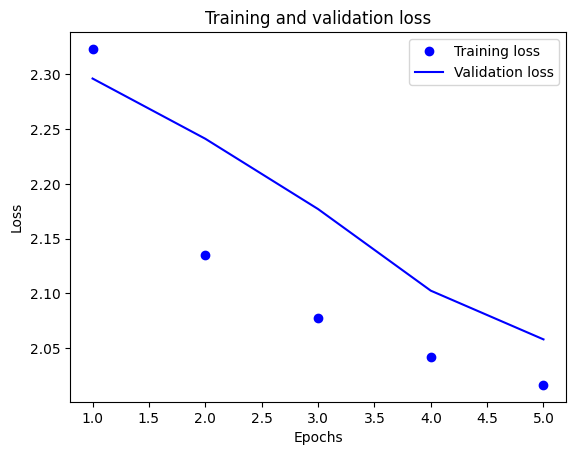

In [ ]:
plot_loss(train_loss_all, val_loss_all)

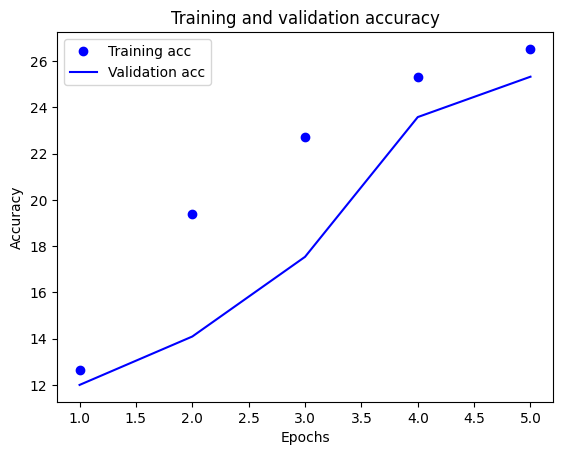

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

# Problema 4

In [ ]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42);

In [ ]:
rnn = nn.RNN(input_size = 7, hidden_size = 5, num_layers = 3)

mean = 0.0
std = 0.01

# input_data = torch.randn(15, 1,7) * std + mean

input_data = torch.normal(mean, std, (15, 1, 7))

h0 = torch.ones(3, 1, 5)

output, hn = rnn(input_data, h0)

print("Output : \n")
print(output)

print("Output shape : \n")
print(output.shape)

print("hidden state : \n")
print(hn)


Output : 

tensor([[[-0.4928, -0.1063, -0.3940,  0.1416, -0.0074]],

        [[-0.0787,  0.2089,  0.3458, -0.0401,  0.1788]],

        [[-0.1749,  0.4246, -0.0250,  0.0497,  0.3353]],

        [[-0.2351,  0.3111,  0.0706, -0.0968,  0.3992]],

        [[-0.2178,  0.3773, -0.0506, -0.0186,  0.4222]],

        [[-0.2320,  0.3408, -0.0017, -0.0690,  0.4125]],

        [[-0.2166,  0.3695, -0.0356, -0.0400,  0.4255]],

        [[-0.2273,  0.3567, -0.0251, -0.0578,  0.4228]],

        [[-0.2236,  0.3631, -0.0333, -0.0501,  0.4247]],

        [[-0.2235,  0.3603, -0.0291, -0.0522,  0.4265]],

        [[-0.2250,  0.3615, -0.0330, -0.0513,  0.4257]],

        [[-0.2245,  0.3594, -0.0293, -0.0527,  0.4224]],

        [[-0.2218,  0.3618, -0.0288, -0.0505,  0.4249]],

        [[-0.2235,  0.3600, -0.0297, -0.0499,  0.4243]],

        [[-0.2235,  0.3607, -0.0289, -0.0521,  0.4231]]],
       grad_fn=<StackBackward0>)
Output shape : 

torch.Size([15, 1, 5])
hidden state : 

tensor([[[ 0.1883,  0.2537, -

# Problema 5

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

torch.manual_seed(42);

In [ ]:
n_train = 200  # No. of training examples
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # Training inputs

In [ ]:
def f(x):
    return (-2) * torch.cosh(x) + x * torch.tanh(x)

In [ ]:
y_train = f(x_train) + torch.normal(0.0, 0.25, (n_train,))  # Training outputs

x_test = torch.arange(0, 5, 0.025)  # Testing examples
y_truth = f(x_test)  # Ground-truth outputs for the testing examples
n_test = len(x_test)  # No. of testing examples
n_test

200

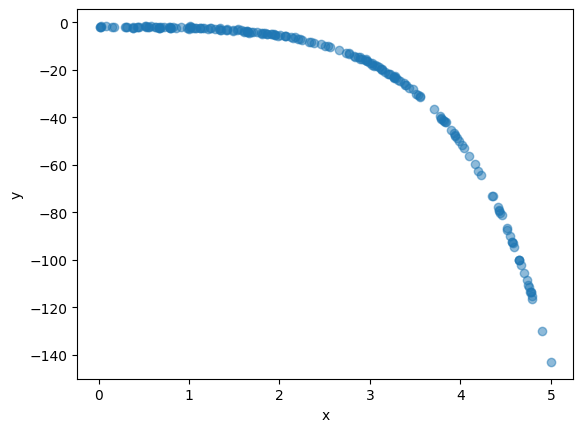

In [ ]:
def plot_training_data():
  plt.xlabel('x')
  plt.ylabel('y')
  plt.plot(x_train, y_train, 'o', alpha = 0.5)

plot_training_data()

In [ ]:
def plot_kernel_reg(y_hat):
    plt.plot(x_test, y_truth, label='Truth')
    plt.plot(x_test, y_hat, label='Pred')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim([0, 5])
    plt.ylim([1, -150])
    plt.legend()
    plt.plot(x_train, y_train, 'o', alpha=0.5);

In [ ]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # Shape of the output `queries` and `attention_weights` is:
        # (no. of queries, no. of key-value pairs)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = F.softmax(-((queries - keys) * self.w)**2 / 2, dim=1)
        # Shape of `values` is: (no. of queries, no. of key-value pairs)
        # print the learned parameter w
        print(self.w)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [ ]:
# Shape of `X_tile` is: (`n_train`, `n_train`), where each column contains the
# same training inputs
X_tile = x_train.repeat((n_train, 1))
# Shape of `Y_tile` is: (`n_train`, `n_train`), where each column contains the
# same training outputs
Y_tile = y_train.repeat((n_train, 1))
# Shape of `keys` is: ('n_train', 'n_train' - 1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# Shape of `values` is: ('n_train', 'n_train' - 1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

In [ ]:
def plot_loss_regression(train_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'b', label='Train loss')
    plt.title('Training loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

Parameter containing:
tensor([0.2203], requires_grad=True)
epoch 1, loss 201478.265625
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 2, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 3, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 4, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 5, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 6, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 7, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 8, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 9, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 10, loss 434.907074
Parameter containing:
tensor([124221.9531], requires_grad=True)
epoch 11, loss 434.907074
Parameter containing:

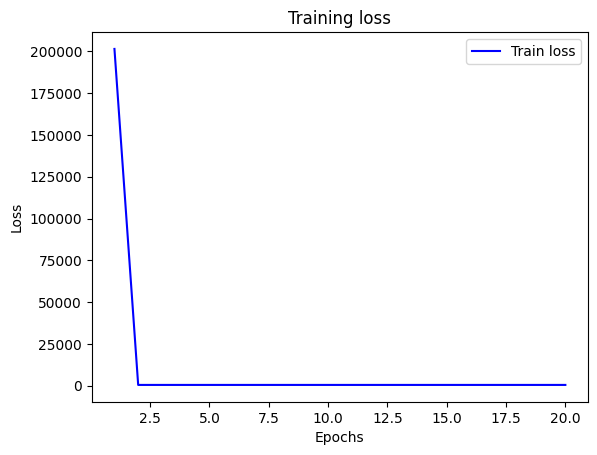

In [ ]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
optimizer = torch.optim.SGD(net.parameters(), lr=0.5)

train_loss_all = []
for epoch in range(20):
    optimizer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    optimizer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    train_loss_all.append(float(l.sum()))

plot_loss_regression(train_loss_all)

Parameter containing:
tensor([124221.9531], requires_grad=True)


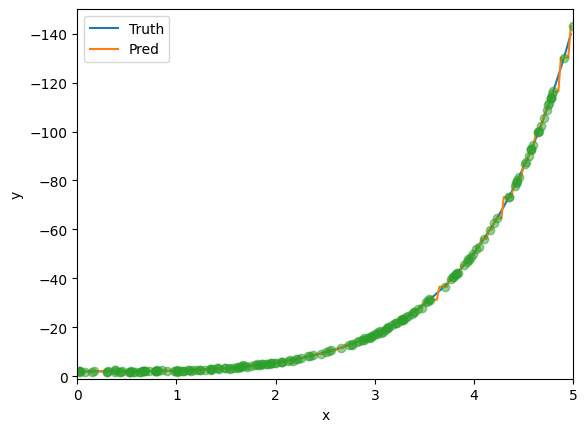

In [ ]:
# Shape of `keys` is: (`n_test`, `n_train`), where each column contains the same
# training inputs (i.e., same keys)
keys = x_train.repeat((n_test, 1))
# Shape of `value` is: (`n_test`, `n_train`)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

In [ ]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

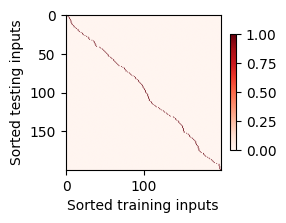

In [ ]:
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs',
              ylabel='Sorted testing inputs')